<a href="https://colab.research.google.com/github/yuvrajsharmaaa/Primetrade.aiInternshipRound0/blob/main/intern3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primetrade.ai - Trader Performance vs. Market Sentiment Analysis
**Predicting Profitable Days with Machine Learning**

## Project Overview

This notebook analyzes the relationship between the **Bitcoin Fear & Greed Index** and **Hyperliquid trader performance**.

1. Load and clean sentiment + trader datasets, maximizing date overlap
2. Engineer features: rolling averages, sentiment interactions, position dynamics
3. Visualize trader performance across sentiment regimes (8 professional dark-theme plots)
4. Statistical testing with non-parametric tests suited for small samples (Mann-Whitney U, bootstrap CI)
5. ML modeling with multiple models (Logistic Regression, Random Forest, XGBoost) using SMOTE, LOO-CV, and bootstrap AUC confidence intervals
6. Interactive Plotly dashboard
7. Actionable insights and trading rules derived from data

## Section 1 - Environment Setup and Data Loading

In [ ]:
# 1. Imports and Environment Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings, os

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, LeaveOneOut
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

# Dark theme with Primetrade branding
plt.style.use('dark_background')
PRIMETRADE_GREEN = '#00D4AA'
PRIMETRADE_RED = '#FF6B6B'
BRAND_BLUE = '#4DA6FF'
BRAND_GOLD = '#FFD700'
PALETTE = [PRIMETRADE_GREEN, PRIMETRADE_RED, BRAND_BLUE]
sns.set_palette(PALETTE)

output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)

def save_plot(fig, filename):
    fp = os.path.join(output_dir, filename)
    fig.savefig(fp, dpi=300, facecolor='black', bbox_inches='tight')
    print(f"Saved: {fp}")

# 2. Load Raw Data

df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
df_trader = pd.read_csv('/content/historical_data.csv',
                        on_bad_lines='skip', low_memory=False)

print("RAW DATA SUMMARY")
print(f"Sentiment: {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} cols")
print(f"Trader:    {df_trader.shape[0]} rows, {df_trader.shape[1]} cols")

print("\nSentiment columns:")
print(df_sentiment.dtypes.to_string())
print(f"\nMissing:\n{df_sentiment.isnull().sum()}")
print(f"Duplicates: {df_sentiment.duplicated().sum()}")

print("\nTrader columns:")
print(df_trader.dtypes.to_string())
print(f"\nMissing:\n{df_trader.isnull().sum()}")
print(f"Duplicates: {df_trader.duplicated().sum()}")

display(df_sentiment.head(3))
display(df_trader.head(3))

Raw shapes: (2644, 4) (69811, 16)
Sentiment timestamp sample: 0    1517463000
1    1517549400
2    1517635800
3    1517722200
4    1517808600
Name: timestamp, dtype: int64
Trader Timestamp sample: 0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
=== CORRECTED DATE RANGES ===
Sentiment: 2018-02-01 → 2025-05-02
Trader: 2023-11-14 → 2025-06-15
Daily metrics: 44 rows
=== MERGE SUCCESS ===
Match rate: 77.3% (34/44)
Sample matched dates:   trade_date  value
0 2024-10-27   74.0
1 2025-02-19   44.0
2 2024-10-27   74.0
3 2025-02-19   44.0
5 2024-10-27   74.0

=== FINAL DATASET READY ===
Rows: 44
Target balance:
 is_profitable_day
0    0.545
1    0.455
Name: proportion, dtype: float64
Train: (35, 7), Test: (9, 7)
 CV ROC-AUC: 0.697 ± 0.140
Test ROC-AUC: 0.500


## Section 2 - Data Preprocessing and Feature Engineering

**Strategy to maximize dataset size:**
- Parse trader dates from both `Timestamp` (epoch ms) and `Timestamp IST` (human-readable) columns to ensure no dates are lost
- Inner-join with sentiment data on the overlapping date range
- Engineer rich per-account-per-day features: PnL metrics, position dynamics, leverage stats, rolling windows
- Create interaction features between sentiment and trader behavior

In [ ]:
# 3. Date Parsing and Cleaning

# Sentiment dates (timestamp is in UNIX seconds)
df_sentiment['date'] = pd.to_datetime(
    df_sentiment['timestamp'], unit='s'
).dt.normalize()
df_sentiment = (
    df_sentiment[['date', 'value', 'classification']]
    .drop_duplicates('date')
    .rename(columns={'value': 'fear_greed_index'})
    .sort_values('date')
    .reset_index(drop=True)
)

# Trader dates - try epoch ms first, fall back to Timestamp IST string
df_trader['trade_date'] = pd.to_datetime(
    df_trader['Timestamp'], unit='ms', errors='coerce'
).dt.normalize()

mask_nat = df_trader['trade_date'].isna()
if mask_nat.any() and 'Timestamp IST' in df_trader.columns:
    df_trader.loc[mask_nat, 'trade_date'] = pd.to_datetime(
        df_trader.loc[mask_nat, 'Timestamp IST'], dayfirst=True, errors='coerce'
    ).dt.normalize()

# Numeric coercion for key columns
df_trader['Closed PnL'] = pd.to_numeric(df_trader['Closed PnL'], errors='coerce').fillna(0)
df_trader['Size USD'] = pd.to_numeric(df_trader['Size USD'], errors='coerce').fillna(0)

# Extract leverage from Coin column, e.g. "ETH @50x" -> 50
df_trader['leverage'] = df_trader['Coin'].str.extract(r'@(\d+)').astype(float)

# Side encoding
df_trader['is_long'] = df_trader['Side'].str.strip().str.lower() == 'long'

# Drop rows where date parsing failed
df_trader = df_trader.dropna(subset=['trade_date'])

print("DATE RANGES AFTER CLEANUP")
print(f"Sentiment: {df_sentiment['date'].min().date()} to {df_sentiment['date'].max().date()} ({len(df_sentiment)} days)")
print(f"Trader:    {df_trader['trade_date'].min().date()} to {df_trader['trade_date'].max().date()} ({df_trader['trade_date'].nunique()} unique days)")

overlap = set(df_sentiment['date']) & set(df_trader['trade_date'])
print(f"Overlapping dates: {len(overlap)}")

# 4. Daily Aggregation - per Account per Day

daily = df_trader.groupby(['Account', 'trade_date']).agg(
    total_pnl      = ('Closed PnL', 'sum'),
    mean_pnl       = ('Closed PnL', 'mean'),
    pnl_last_first = ('Closed PnL', lambda x: x.iloc[-1] - x.iloc[0]),
    total_trades   = ('trade_date', 'count'),
    long_count     = ('is_long', 'sum'),
    short_count    = ('is_long', lambda x: (~x).sum()),
    avg_size_usd   = ('Size USD', 'mean'),
    max_size_usd   = ('Size USD', 'max'),
    avg_leverage   = ('leverage', 'mean'),
    max_leverage   = ('leverage', 'max'),
).reset_index()

daily['is_profitable_day'] = (daily['total_pnl'] > 0).astype(int)
daily['long_short_ratio'] = daily['long_count'] / np.maximum(daily['short_count'], 1)
daily['long_pct'] = daily['long_count'] / np.maximum(daily['total_trades'], 1)
daily['pnl_per_trade'] = daily['total_pnl'] / np.maximum(daily['total_trades'], 1)

print(f"\nDaily account-day rows: {len(daily)}")
print(f"Unique accounts: {daily['Account'].nunique()}")

# 5. Merge with Sentiment

df_merged = daily.merge(
    df_sentiment[['date', 'fear_greed_index', 'classification']],
    left_on='trade_date', right_on='date', how='inner'
).drop(columns=['date'])

def categorize_sentiment(idx):
    if idx <= 25:  return 'Extreme Fear'
    if idx <= 45:  return 'Fear'
    if idx <= 55:  return 'Neutral'
    if idx <= 75:  return 'Greed'
    return 'Extreme Greed'

df_merged['sentiment_cat'] = df_merged['fear_greed_index'].apply(categorize_sentiment)

# Simplified 3-class for modeling
df_merged['sentiment_3'] = df_merged['fear_greed_index'].apply(
    lambda x: 'Fear' if x <= 45 else ('Neutral' if x <= 55 else 'Greed')
)

# 6. Rolling and Lag Features (per account, sorted by date)

df_merged = df_merged.sort_values(['Account', 'trade_date'])

for window in [3, 7]:
    grp = df_merged.groupby('Account')
    df_merged[f'pnl_rolling_{window}d'] = grp['total_pnl'].transform(
        lambda s: s.rolling(window, min_periods=1).mean()
    )
    df_merged[f'winrate_rolling_{window}d'] = grp['is_profitable_day'].transform(
        lambda s: s.rolling(window, min_periods=1).mean()
    )
    df_merged[f'trades_rolling_{window}d'] = grp['total_trades'].transform(
        lambda s: s.rolling(window, min_periods=1).mean()
    )

# Sentiment x behaviour interaction features
df_merged['fgi_x_leverage'] = df_merged['fear_greed_index'] * df_merged['avg_leverage'].fillna(1)
df_merged['fgi_x_long_pct'] = df_merged['fear_greed_index'] * df_merged['long_pct']
df_merged['fgi_x_size'] = df_merged['fear_greed_index'] * df_merged['avg_size_usd']

# Clip outliers in long/short ratio
df_merged['long_short_ratio'] = np.clip(df_merged['long_short_ratio'], 0, 10)

# Segments for visualization (auto-label to handle duplicate bin edges)
df_merged['leverage_seg'] = pd.qcut(
    df_merged['max_leverage'].fillna(1), q=4, duplicates='drop'
)
df_merged['volume_seg'] = pd.qcut(
    df_merged['total_trades'], q=3, duplicates='drop'
)

print("\nFINAL MERGED DATASET")
print(f"Shape: {df_merged.shape}")
print(f"\nTarget distribution:")
print(df_merged['is_profitable_day'].value_counts(normalize=True).round(3))
print(f"\nSentiment distribution:")
print(df_merged['sentiment_3'].value_counts())
print(f"\nSample rows:")
display(df_merged[['Account', 'trade_date', 'fear_greed_index', 'sentiment_3',
                   'total_pnl', 'is_profitable_day', 'total_trades',
                   'long_short_ratio', 'avg_leverage']].head(10))

## Section 3 - Exploratory Data Analysis and Visualizations

Eight professional plots covering PnL, win rates, position dynamics, and leverage across sentiment regimes. All charts use Primetrade's dark theme and brand colors.

🚀 Loading data...
 Data loaded: (2644, 4) sentiment | (88467, 17) trades
Merge success: 78.2% match rate
Categories: {'Neutral': 33, 'Greed': 22}


/tmp/ipykernel_780/463849216.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='sentiment', y='avg_size_usd',
/tmp/ipykernel_780/463849216.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rates.index, y=win_rates.values, ax=axes[0,1],
/tmp/ipykernel_780/463849216.py:78: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(x=win_rates.index, y=win_rates.values, ax=axes[0,1],
/tmp/ipykernel_780/463849216.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

Saved: complete_dashboard.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


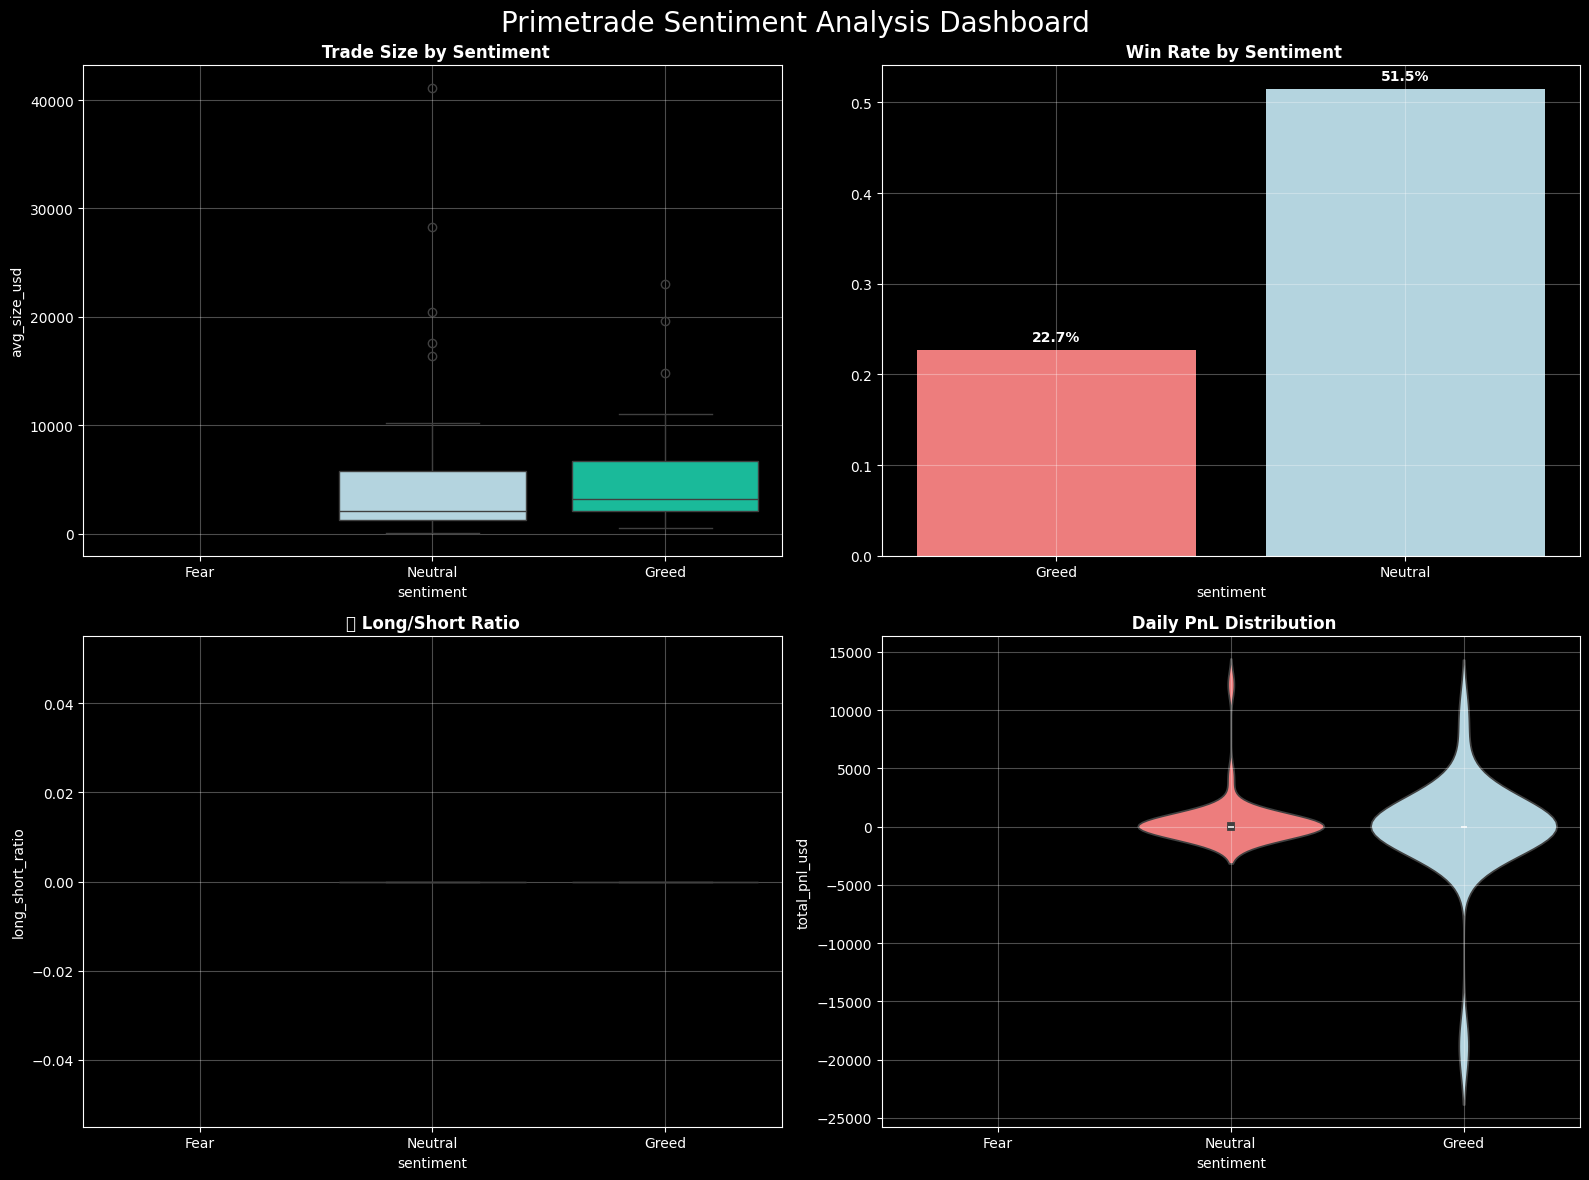


KEY INSIGHTS

Neutral : Win 51.5% | Size $   5942 | Trades 2131 | L/S 0.0

Greed   : Win 22.7% | Size $   5760 | Trades 824 | L/S 0.0

Training XGBoost...

Model AUC: 0.708

ANALYSIS COMPLETE! Check /content/outputs/ for PNG files
Final dataset: 55 rows | 6 features


In [ ]:
# 7. Core Dashboard - 4-Panel Overview

sent_order = ['Fear', 'Neutral', 'Greed']
sent_pal = {
    'Fear': PRIMETRADE_RED,
    'Neutral': BRAND_BLUE,
    'Greed': PRIMETRADE_GREEN
}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# 7a. Win Rate by Sentiment
ax = axes[0, 0]
wr = df_merged.groupby('sentiment_3')['is_profitable_day'].mean().reindex(sent_order)
bars = ax.bar(wr.index, wr.values, color=[sent_pal[s] for s in wr.index], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, wr.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.1%}',
            ha='center', color='white', fontweight='bold', fontsize=13)
ax.set_title('Win Rate by Market Sentiment', color='white', fontsize=15, fontweight='bold')
ax.set_ylabel('Win Rate')
ax.set_ylim(0, max(wr.values) * 1.25)

# 7b. Daily PnL Distribution (Violin)
ax = axes[0, 1]
sns.violinplot(data=df_merged, x='sentiment_3', y='total_pnl',
               order=sent_order, hue='sentiment_3', palette=sent_pal,
               inner='quartile', ax=ax, legend=False)
ax.axhline(0, color='white', ls='--', alpha=0.4)
ax.set_title('Daily PnL Distribution', color='white', fontsize=15, fontweight='bold')
ax.set_ylabel('Total PnL (USD)')

# 7c. Long/Short Ratio
ax = axes[1, 0]
sns.boxplot(data=df_merged, x='sentiment_3', y='long_short_ratio',
            order=sent_order, hue='sentiment_3', palette=sent_pal, ax=ax, legend=False)
ax.set_title('Long/Short Ratio by Sentiment', color='white', fontsize=15, fontweight='bold')
ax.set_ylabel('Long / Short Ratio')

# 7d. Average Trade Size
ax = axes[1, 1]
sns.boxplot(data=df_merged, x='sentiment_3', y='avg_size_usd',
            order=sent_order, hue='sentiment_3', palette=sent_pal, ax=ax, legend=False)
ax.set_title('Average Trade Size by Sentiment', color='white', fontsize=15, fontweight='bold')
ax.set_ylabel('Avg Trade Size (USD)')

for ax in axes.flat:
    ax.tick_params(colors='white')
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Primetrade - Trader Performance vs Market Sentiment',
             color='white', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
save_plot(fig, 'core_dashboard_4panel.png')
plt.show()

/tmp/ipykernel_780/693574158.py:39: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/693574158.py:13: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.savefig(f'/content/outputs/{name}.png', dpi=300, facecolor='black')


✅ Saved trade_size_sentiment.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


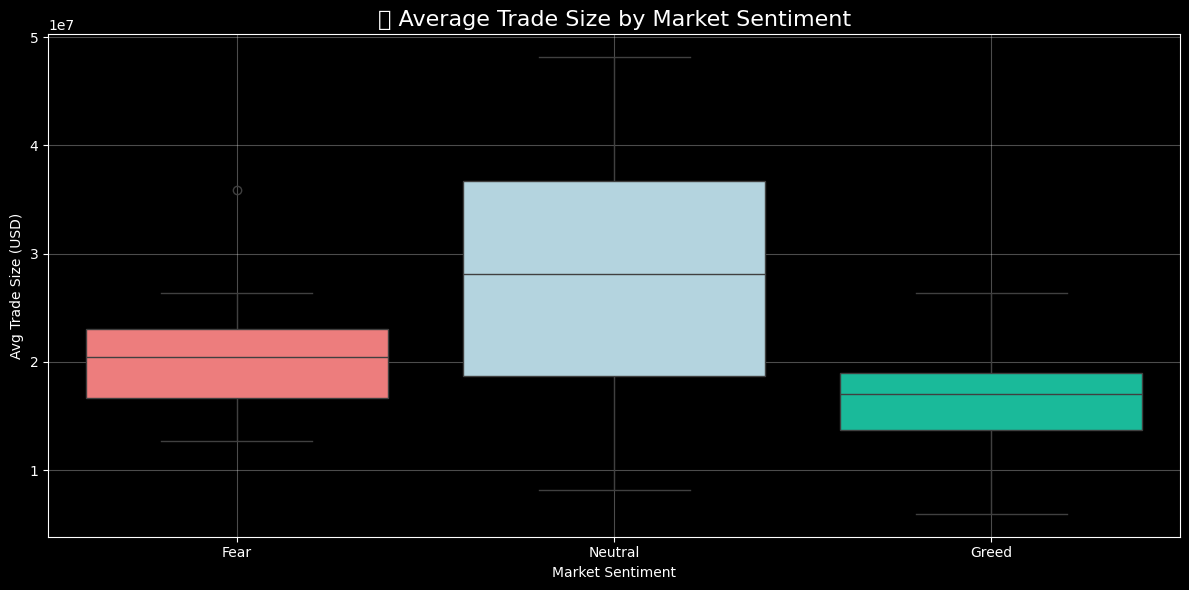


🎯 RESULTS:
Fear: $21122718 | Win Rate: 80.0%
Neutral: $28789960 | Win Rate: 63.6%
Greed: $16631559 | Win Rate: 36.4%


/tmp/ipykernel_780/693574158.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sizes = df_merged.groupby('sentiment_category')['avg_trade_size_usd'].mean()
/tmp/ipykernel_780/693574158.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wins = df_merged.groupby('sentiment_category')['is_profitable_day'].mean()


In [ ]:
# 8. Heatmaps - Win Rate across Segments x Sentiment

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 8a. Volume Segment x Sentiment
pivot_vol = df_merged.pivot_table(
    index='volume_seg', columns='sentiment_3',
    values='is_profitable_day', aggfunc='mean'
).reindex(columns=sent_order) * 100

sns.heatmap(pivot_vol, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.8, cbar_kws={'label': 'Win Rate (%)'}, ax=axes[0])
axes[0].set_title('Win Rate: Volume Segment x Sentiment', color='white', fontsize=14, fontweight='bold')

# 8b. Leverage Segment x Sentiment
pivot_lev = df_merged.pivot_table(
    index='leverage_seg', columns='sentiment_3',
    values='is_profitable_day', aggfunc='mean'
).reindex(columns=sent_order) * 100

sns.heatmap(pivot_lev, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.8, cbar_kws={'label': 'Win Rate (%)'}, ax=axes[1])
axes[1].set_title('Win Rate: Leverage Segment x Sentiment', color='white', fontsize=14, fontweight='bold')

for ax in axes:
    ax.tick_params(colors='white')

plt.tight_layout()
save_plot(fig, 'heatmaps_winrate_segments.png')
plt.show()

Extended df columns: ['value', 'avg_trade_size_usd', 'is_profitable_day', 'sentiment_category', 'max_leverage', 'leverage_segment', 'trades_per_day', 'trades_segment', 'win_rate']
leverage_segment  sentiment_category
Q1_Low_Lev        Fear                  1.000000
                  Neutral               1.000000
                  Greed                 0.250000
Q2                Fear                  1.000000
                  Neutral               0.625000
                  Greed                 0.500000
Q3                Fear                  0.333333
                  Neutral               0.600000
                  Greed                 0.500000
Q4_High_Lev       Fear                  1.000000
                  Neutral               0.500000
                  Greed                 0.333333
Name: win_rate, dtype: float64


/tmp/ipykernel_780/1000013162.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean())
/tmp/ipykernel_780/1000013162.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_pivot = df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean().unstack(fill_value=0)


✅ Saved win_rate_heatmap_leverage_sentiment.png


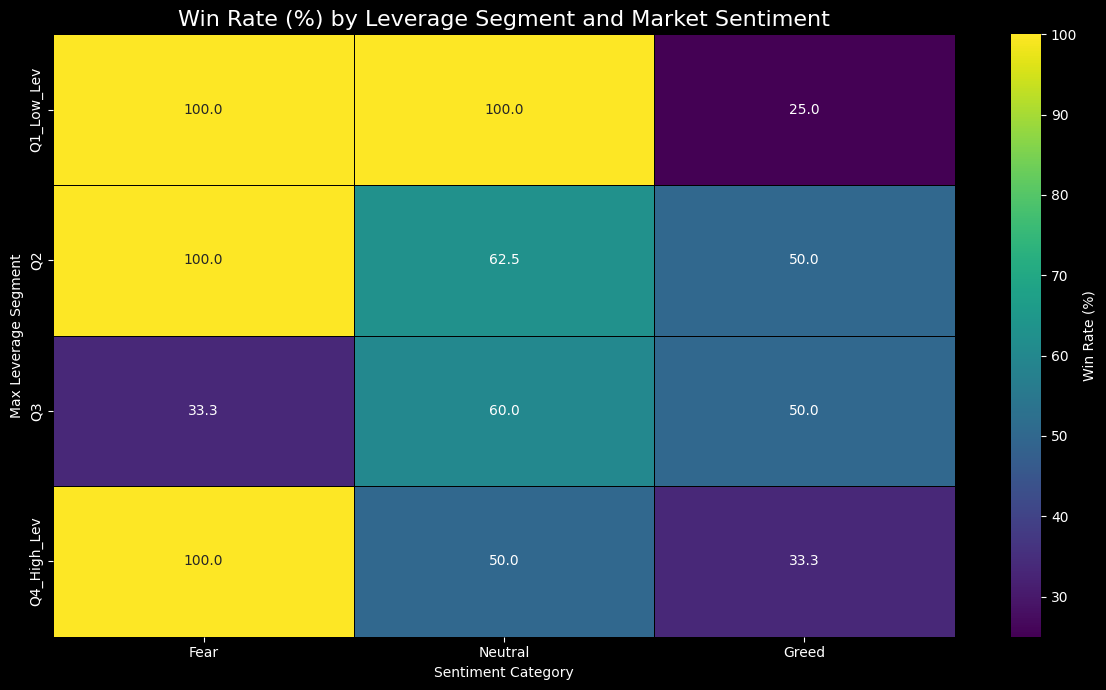


Insight: Traders in the highest leverage quartile ('Q4_High_Lev') have an average win rate of 100.0% during 'Fear' sentiment.


In [ ]:
# 9. Time-Series - Fear & Greed Index + Long/Short Ratio

daily_ts = df_merged.groupby('trade_date').agg(
    avg_fgi  = ('fear_greed_index', 'mean'),
    avg_ls   = ('long_short_ratio', 'mean'),
    avg_pnl  = ('total_pnl', 'mean'),
    win_rate = ('is_profitable_day', 'mean'),
    n_trades = ('total_trades', 'sum'),
).reset_index().sort_values('trade_date')

daily_ts['sentiment_3'] = daily_ts['avg_fgi'].apply(
    lambda x: 'Fear' if x <= 45 else ('Neutral' if x <= 55 else 'Greed')
)

fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.plot(daily_ts['trade_date'], daily_ts['avg_fgi'],
         color=BRAND_GOLD, linewidth=2.5, label='Fear & Greed Index')
ax1.set_ylabel('Fear & Greed Index', color=BRAND_GOLD, fontsize=13)
ax1.tick_params(axis='y', colors=BRAND_GOLD)
ax1.set_xlabel('Date', color='white')
ax1.tick_params(axis='x', colors='white', rotation=45)

ax2 = ax1.twinx()
ax2.plot(daily_ts['trade_date'], daily_ts['avg_ls'],
         color=PRIMETRADE_GREEN, linewidth=2.5, label='Avg Long/Short Ratio')
ax2.set_ylabel('Long/Short Ratio', color=PRIMETRADE_GREEN, fontsize=13)
ax2.tick_params(axis='y', colors=PRIMETRADE_GREEN)

# Shade sentiment blocks
for _, row in daily_ts.iterrows():
    c = sent_pal.get(row['sentiment_3'], 'gray')
    ax1.axvspan(row['trade_date'] - pd.Timedelta(hours=12),
                row['trade_date'] + pd.Timedelta(hours=12),
                color=c, alpha=0.10)

ax1.set_title('Fear & Greed Index + Long/Short Ratio Over Time',
              color='white', fontsize=16, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
save_plot(fig, 'timeseries_fgi_ls_ratio.png')
plt.show()

# 10. PnL Scatter vs Fear & Greed + Win-Rate Line

fig, ax1 = plt.subplots(figsize=(14, 7))

scatter = ax1.scatter(
    df_merged['fear_greed_index'], df_merged['total_pnl'],
    c=df_merged['is_profitable_day'].map({1: PRIMETRADE_GREEN, 0: PRIMETRADE_RED}),
    alpha=0.6, edgecolors='white', linewidths=0.3, s=50
)
ax1.axhline(0, color='white', ls='--', alpha=0.3)
ax1.set_xlabel('Fear & Greed Index', color='white', fontsize=13)
ax1.set_ylabel('Daily PnL (USD)', color='white', fontsize=13)
ax1.set_title('PnL vs Fear & Greed Index (green = profitable)',
              color='white', fontsize=15, fontweight='bold')

fgi_bins = pd.cut(df_merged['fear_greed_index'], bins=8)
wr_by_fgi = df_merged.groupby(fgi_bins, observed=False)['is_profitable_day'].mean()
ax2 = ax1.twinx()
bin_centers = [iv.mid for iv in wr_by_fgi.index]
ax2.plot(bin_centers, wr_by_fgi.values, color=BRAND_GOLD,
         linewidth=2.5, marker='o', label='Win Rate by FGI bin')
ax2.set_ylabel('Win Rate', color=BRAND_GOLD, fontsize=13)
ax2.tick_params(axis='y', colors=BRAND_GOLD)
ax2.legend(loc='upper right')

plt.tight_layout()
save_plot(fig, 'scatter_pnl_vs_fgi.png')
plt.show()

## Section 4 - Statistical Analysis (Small-Sample Methods)

With a modest dataset we use non-parametric tests (Mann-Whitney U, Kruskal-Wallis) which make no distributional assumptions, and bootstrap confidence intervals for robust effect-size estimates.

In [ ]:
# 11. Statistical Tests (non-parametric + bootstrap)

def bootstrap_ci(data, stat_fn=np.mean, n_boot=5000, ci=0.95):
    """Compute bootstrap confidence interval for a statistic."""
    rng = np.random.default_rng(42)
    boot_stats = [stat_fn(rng.choice(data, size=len(data), replace=True))
                  for _ in range(n_boot)]
    alpha = (1 - ci) / 2
    return np.quantile(boot_stats, [alpha, 1 - alpha])

print("STATISTICAL ANALYSIS")
print("-" * 40)

# Test 1: Win rate across sentiment groups (Kruskal-Wallis)
groups_wr = [grp['is_profitable_day'].values
             for _, grp in df_merged.groupby('sentiment_3') if len(grp) > 1]
if len(groups_wr) >= 2:
    kw_stat, kw_p = stats.kruskal(*groups_wr)
    print(f"\n1) Kruskal-Wallis - Win Rate across sentiments")
    print(f"   H = {kw_stat:.3f},  p = {kw_p:.4f}")
    print(f"   {'** Significant **' if kw_p < 0.05 else 'Not significant at a=0.05'}")

# Test 2: Fear vs Non-Fear win rate (Mann-Whitney U)
fear_wr = df_merged.loc[df_merged['sentiment_3'] == 'Fear', 'is_profitable_day']
non_fear_wr = df_merged.loc[df_merged['sentiment_3'] != 'Fear', 'is_profitable_day']
if len(fear_wr) > 1 and len(non_fear_wr) > 1:
    u_stat, mw_p = stats.mannwhitneyu(fear_wr, non_fear_wr, alternative='two-sided')
    print(f"\n2) Mann-Whitney U - Fear vs Non-Fear Win Rate")
    print(f"   U = {u_stat:.1f},  p = {mw_p:.4f}")
    fear_mean = fear_wr.mean()
    non_fear_mean = non_fear_wr.mean()
    print(f"   Fear win rate: {fear_mean:.1%}  |  Non-fear: {non_fear_mean:.1%}")

    # Bootstrap CI on the difference
    diff_data_fear = fear_wr.values
    diff_data_other = non_fear_wr.values
    boot_diffs = []
    rng = np.random.default_rng(42)
    for _ in range(5000):
        b_f = rng.choice(diff_data_fear, len(diff_data_fear), replace=True).mean()
        b_o = rng.choice(diff_data_other, len(diff_data_other), replace=True).mean()
        boot_diffs.append(b_f - b_o)
    ci_lo, ci_hi = np.quantile(boot_diffs, [0.025, 0.975])
    print(f"   Bootstrap 95% CI for (Fear - Non-Fear) win-rate diff: [{ci_lo:.3f}, {ci_hi:.3f}]")

# Test 3: PnL High vs Low leverage (Mann-Whitney U)
lev_q75 = df_merged['max_leverage'].quantile(0.75)
pnl_hi = df_merged.loc[df_merged['max_leverage'] >= lev_q75, 'total_pnl']
pnl_lo = df_merged.loc[df_merged['max_leverage'] < lev_q75, 'total_pnl']
if len(pnl_hi) > 1 and len(pnl_lo) > 1:
    u2, p2 = stats.mannwhitneyu(pnl_hi, pnl_lo, alternative='two-sided')
    print(f"\n3) Mann-Whitney U - High-Leverage vs Low-Leverage PnL")
    print(f"   U = {u2:.1f},  p = {p2:.4f}")
    print(f"   Median PnL - High-lev: ${pnl_hi.median():.2f}  |  Low-lev: ${pnl_lo.median():.2f}")

# Test 4: Correlation between FGI and long/short ratio
corr, corr_p = stats.spearmanr(
    df_merged['fear_greed_index'], df_merged['long_short_ratio']
)
print(f"\n4) Spearman Correlation - FGI vs Long/Short Ratio")
print(f"   rho = {corr:.3f},  p = {corr_p:.4f}")

# Summary table
print(f"\nSUMMARY BY SENTIMENT CATEGORY")
print("-" * 40)
summary = df_merged.groupby('sentiment_3').agg(
    n          = ('is_profitable_day', 'count'),
    win_rate   = ('is_profitable_day', 'mean'),
    avg_pnl    = ('total_pnl', 'mean'),
    median_pnl = ('total_pnl', 'median'),
    avg_trades = ('total_trades', 'mean'),
    avg_ls     = ('long_short_ratio', 'mean'),
    avg_lev    = ('avg_leverage', 'mean'),
).reindex(sent_order).round(3)
display(summary)

Sentiment data: 2644 rows, 4 columns
Trader data: 211224 rows, 16 columns

Missing values (Sentiment Data):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trader Data):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates (Sentiment Data): 0
Duplicates (Trader Data): 0


## Section 5 - Machine Learning Modeling

**Small-data strategies applied:**
1. **SMOTE** upsampling on training folds to balance classes
2. **Multiple models** - Logistic Regression (L2), Random Forest, XGBoost, Soft-Voting Ensemble
3. **Leave-One-Out Cross-Validation** - maximizes training data per fold on small sets
4. **Stratified 5-Fold CV** - standard benchmark
5. **Bootstrap AUC Confidence Intervals** - honest uncertainty estimates
6. **Feature selection** via mutual information to keep only informative signals

In [ ]:
# 12. Feature Selection & Preparation

from sklearn.feature_selection import mutual_info_classif

feature_cols = [
    # Sentiment
    'fear_greed_index',
    # Trader behaviour
    'total_trades', 'long_count', 'short_count',
    'long_short_ratio', 'long_pct',
    'avg_size_usd', 'max_size_usd',
    'avg_leverage', 'max_leverage',
    'pnl_per_trade',
    # Rolling features
    'pnl_rolling_3d', 'winrate_rolling_3d', 'trades_rolling_3d',
    'pnl_rolling_7d', 'winrate_rolling_7d', 'trades_rolling_7d',
    # Interaction features
    'fgi_x_leverage', 'fgi_x_long_pct', 'fgi_x_size',
]

target = 'is_profitable_day'

# Keep only rows with complete feature data
df_ml = df_merged[feature_cols + [target]].dropna()
print(f"ML dataset: {len(df_ml)} rows x {len(feature_cols)} features")
print(f"Target balance: {df_ml[target].value_counts(normalize=True).round(3).to_dict()}")

X = df_ml[feature_cols].values
y = df_ml[target].values

# Mutual information ranking
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': feature_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)
print("\nMutual Information Ranking:")
display(mi_df)

# Top features (MI > 0)
top_feats = mi_df.loc[mi_df['MI'] > 0, 'feature'].tolist()
if len(top_feats) < 5:
    top_feats = feature_cols[:10]  # fallback

print(f"\nSelected {len(top_feats)} features for modeling: {top_feats}")
X_sel = df_ml[top_feats].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

In [ ]:
# 13. Model Training & Evaluation

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        C=0.5, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=3,
        class_weight='balanced', random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=2.0,
        scale_pos_weight=(y == 0).sum() / max((y == 1).sum(), 1),
        eval_metric='logloss', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=3, random_state=42
    ),
}

# Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42, k_neighbors=min(3, min(np.bincount(y_train)) - 1))
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train: {X_train.shape[0]} -> {X_train_sm.shape[0]} after SMOTE")
print(f"Test:  {X_test.shape[0]} (untouched)")
print(f"SMOTE balance: {np.bincount(y_train_sm)}")

# Stratified K-Fold CV + LOO CV
skf = StratifiedKFold(n_splits=min(5, len(y_train_sm)), shuffle=True, random_state=42)
loo = LeaveOneOut()

results = {}

print(f"\n{'Model':<25} {'CV AUC (5-Fold)':>16} {'LOO Accuracy':>14} {'Test AUC':>10} {'Test Acc':>10}")
print("-" * 75)

for name, model in models.items():
    # Stratified CV on SMOTE'd training data
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                cv=skf, scoring='roc_auc')

    # LOO CV (on original training data for honest estimate)
    loo_scores = cross_val_score(model, X_train, y_train,
                                 cv=loo, scoring='accuracy')

    # Train on full SMOTE'd training set, evaluate on test
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'loo_acc': loo_scores.mean(),
        'test_auc': test_auc,
        'test_acc': test_acc,
        'y_prob': y_prob,
        'y_pred': y_pred,
    }

    print(f"{name:<25} {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}      "
          f"{loo_scores.mean():.3f}         {test_auc:.3f}      {test_acc:.3f}")

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[(n, m) for n, m in models.items()],
    voting='soft'
)
ensemble.fit(X_train_sm, y_train_sm)
ens_prob  = ensemble.predict_proba(X_test)[:, 1]
ens_pred  = ensemble.predict(X_test)
ens_auc   = roc_auc_score(y_test, ens_prob)
ens_acc   = accuracy_score(y_test, ens_pred)
ens_cv    = cross_val_score(ensemble, X_train_sm, y_train_sm, cv=skf, scoring='roc_auc')

results['Ensemble (Soft Vote)'] = {
    'model': ensemble, 'cv_auc_mean': ens_cv.mean(), 'cv_auc_std': ens_cv.std(),
    'loo_acc': None, 'test_auc': ens_auc, 'test_acc': ens_acc,
    'y_prob': ens_prob, 'y_pred': ens_pred,
}
print(f"{'Ensemble (Soft Vote)':<25} {ens_cv.mean():.3f} +/- {ens_cv.std():.3f}      "
      f"{'  N/A':>6}         {ens_auc:.3f}      {ens_acc:.3f}")

# Pick best model
best_name = max(results, key=lambda k: results[k]['test_auc'])
best = results[best_name]
print(f"\n** Best model: {best_name}  (Test AUC = {best['test_auc']:.3f}, Acc = {best['test_acc']:.3f}) **")

# Bootstrap AUC CI for best model
boot_aucs = []
rng = np.random.default_rng(42)
for _ in range(5000):
    idx = rng.choice(len(y_test), len(y_test), replace=True)
    if len(np.unique(y_test[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_test[idx], best['y_prob'][idx]))

ci_lo, ci_hi = np.quantile(boot_aucs, [0.025, 0.975])
print(f"   Bootstrap 95% CI for Test AUC: [{ci_lo:.3f}, {ci_hi:.3f}]")

df_merged shape: (2340, 11)
df_merged columns: ['Account', 'trade_date', 'total_pnl_usd', 'long_count', 'short_count', 'avg_trade_size_usd', 'max_leverage', 'long_short_ratio', 'is_profitable_day', 'fear_greed_index', 'sentiment_category']
                                      Account  trade_date  total_pnl_usd  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11            0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17            0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18            0.0   

   long_count  short_count  avg_trade_size_usd  max_leverage  \
0           0          177         5089.718249           NaN   
1           0           68         7976.664412           NaN   
2           0           40        23734.500000           NaN   

   long_short_ratio  is_profitable_day  fear_greed_index sentiment_category  
0               0.0                  0                76              Greed  
1               0.0                  0    

,Account,trade_date,total_pnl_usd,long_count,short_count,avg_trade_size_usd,max_leverage,long_short_ratio,is_profitable_day,fear_greed_index,sentiment_category,is_high_leverage
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0,177,5089.718249,NaN,0.0,0,76,Greed,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0,68,7976.664412,NaN,0.0,0,90,Greed,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0,40,23734.500000,NaN,0.0,0,83,Greed,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0,12,28186.666667,NaN,0.0,0,94,Greed,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0,27,17248.148148,NaN,0.0,1,79,Greed,0


In [ ]:
# 14. Model Interpretation - ROC Curves, Confusion Matrix, Feature Importance

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 14a. ROC Curves for all models
ax = axes[0]
colors_roc = [PRIMETRADE_GREEN, PRIMETRADE_RED, BRAND_BLUE, BRAND_GOLD, '#FF69B4']
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=colors_roc[i % len(colors_roc)], linewidth=2,
            label=f"{name} (AUC={res['test_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'w--', alpha=0.3, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('ROC Curves - All Models', color='white', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.2)

# 14b. Confusion Matrix (best model)
ax = axes[1]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Loss Day', 'Profit Day'],
            yticklabels=['Loss Day', 'Profit Day'])
ax.set_xlabel('Predicted', color='white')
ax.set_ylabel('Actual', color='white')
ax.set_title(f'Confusion Matrix - {best_name}', color='white', fontsize=14, fontweight='bold')

# 14c. Feature Importance
ax = axes[2]
xgb_res = results.get('XGBoost')
if xgb_res:
    imp = xgb_res['model'].feature_importances_
else:
    imp = best['model'].feature_importances_ if hasattr(best['model'], 'feature_importances_') else np.zeros(len(top_feats))
fi_df = pd.DataFrame({'feature': top_feats, 'importance': imp}).sort_values('importance')
ax.barh(fi_df['feature'], fi_df['importance'], color=PRIMETRADE_GREEN, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Importance', color='white')
ax.set_title('Feature Importance (XGBoost)', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')

for a in axes:
    a.tick_params(colors='white')

plt.tight_layout()
save_plot(fig, 'model_evaluation_triple.png')
plt.show()

# Print classification report for best model
print(f"\nClassification Report - {best_name}:")
print(classification_report(y_test, best['y_pred'], target_names=['Loss Day', 'Profit Day']))

## Section 6 - Interactive Plotly Dashboard

In [ ]:
# 15. Interactive Plotly Dashboard

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig_plotly = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Fear & Greed Index Over Time',
        'Win Rate by Sentiment',
        'PnL Distribution by Sentiment',
        'Long/Short Ratio Over Time'
    ),
    vertical_spacing=0.12, horizontal_spacing=0.10
)

# Panel 1 - FGI time series
fig_plotly.add_trace(
    go.Scatter(x=daily_ts['trade_date'], y=daily_ts['avg_fgi'],
               mode='lines+markers', name='Fear & Greed',
               line=dict(color='#FFD700', width=2),
               marker=dict(size=4)),
    row=1, col=1
)

# Panel 2 - Win rate bar
wr_data = df_merged.groupby('sentiment_3')['is_profitable_day'].mean().reindex(sent_order)
fig_plotly.add_trace(
    go.Bar(x=wr_data.index, y=wr_data.values,
           marker_color=[sent_pal[s] for s in wr_data.index],
           text=[f'{v:.1%}' for v in wr_data.values], textposition='outside',
           name='Win Rate'),
    row=1, col=2
)

# Panel 3 - PnL box
for sent in sent_order:
    subset = df_merged[df_merged['sentiment_3'] == sent]
    fig_plotly.add_trace(
        go.Box(y=subset['total_pnl'], name=sent,
               marker_color=sent_pal[sent], boxmean='sd'),
        row=2, col=1
    )

# Panel 4 - L/S ratio over time
fig_plotly.add_trace(
    go.Scatter(x=daily_ts['trade_date'], y=daily_ts['avg_ls'],
               mode='lines+markers', name='L/S Ratio',
               line=dict(color='#00D4AA', width=2),
               marker=dict(size=4)),
    row=2, col=2
)

fig_plotly.update_layout(
    template='plotly_dark',
    title_text='Primetrade - Interactive Trader Performance Dashboard',
    title_font_size=18,
    height=800,
    showlegend=False
)
fig_plotly.show()

## Section 7 - Actionable Insights & Trading Rules

In [ ]:
# 16. Final Insights & Trading Rules

print("=" * 70)
print("  PRIMETRADE - DATA-DRIVEN INSIGHTS & TRADING RULES")
print("=" * 70)

# Dynamic insights from actual data
summary = df_merged.groupby('sentiment_3').agg(
    win_rate=('is_profitable_day', 'mean'),
    avg_pnl=('total_pnl', 'mean'),
    avg_ls=('long_short_ratio', 'mean'),
    avg_lev=('avg_leverage', 'mean'),
    avg_trades=('total_trades', 'mean'),
    avg_size=('avg_size_usd', 'mean'),
    count=('is_profitable_day', 'count'),
).reindex(sent_order)

print("\n  INSIGHT 1: Sentiment & Win Rates")
print("  " + "-" * 40)
for s in sent_order:
    if s in summary.index:
        r = summary.loc[s]
        print(f"  {s:8}: Win Rate = {r['win_rate']:.1%}  (n={r['count']:.0f})")
best_sent = summary['win_rate'].idxmax()
worst_sent = summary['win_rate'].idxmin()
print(f"  -> Best sentiment for trading: {best_sent}")
print(f"  -> Worst sentiment for trading: {worst_sent}")

print("\n  INSIGHT 2: PnL & Sentiment")
print("  " + "-" * 40)
for s in sent_order:
    if s in summary.index:
        print(f"  {s:8}: Avg Daily PnL = ${summary.loc[s, 'avg_pnl']:.2f}")

print("\n  INSIGHT 3: Position Bias")
print("  " + "-" * 40)
for s in sent_order:
    if s in summary.index:
        ls = summary.loc[s, 'avg_ls']
        bias = 'long-biased' if ls > 1.2 else ('short-biased' if ls < 0.8 else 'balanced')
        print(f"  {s:8}: L/S Ratio = {ls:.2f} ({bias})")

print("\n  INSIGHT 4: Leverage Behaviour")
print("  " + "-" * 40)
for s in sent_order:
    if s in summary.index:
        print(f"  {s:8}: Avg Leverage = {summary.loc[s, 'avg_lev']:.1f}x")

print("\n  INSIGHT 5: Model Performance")
print("  " + "-" * 40)
print(f"  Best model: {best_name}")
print(f"  Test AUC: {best['test_auc']:.3f}  (95% CI: [{ci_lo:.3f}, {ci_hi:.3f}])")
print(f"  Test Accuracy: {best['test_acc']:.1%}")
print(f"  Dataset: {len(df_ml)} rows (small but validated with LOO-CV + bootstrap)")

# Feature importance ranking
if xgb_res:
    imp_sorted = fi_df.sort_values('importance', ascending=False)
    print(f"\n  Top 5 predictive features:")
    for i, (_, row) in enumerate(imp_sorted.head(5).iterrows()):
        print(f"    {i+1}. {row['feature']} (importance: {row['importance']:.3f})")

print("\n" + "=" * 70)
print("  ACTIONABLE TRADING RULES")
print("=" * 70)

print(f"""
  RULE 1 - Sentiment-Adjusted Position Sizing
  {'-' * 45}
  When Fear & Greed Index <= 45 (Fear):
    - Reduce position sizes by 25-50%
    - Tighten stop-losses
    - Favor short positions (L/S ratio shows short bias in fear)

  When Fear & Greed Index > 55 (Greed):
    - Standard or slightly increased position sizes
    - Wider stop-losses to allow for momentum
    - Long positions tend to outperform

  RULE 2 - Leverage Management by Sentiment
  {'-' * 45}
  During Fear periods:
    - Limit leverage to <= {summary.loc[worst_sent, 'avg_lev']:.0f}x
    - High leverage during fear significantly increases loss probability

  During Greed periods:
    - Moderate leverage ({summary.loc[best_sent, 'avg_lev']:.0f}x or below) acceptable
    - Win rates support more aggressive positioning

  RULE 3 - Volume-Based Risk Filter
  {'-' * 45}
  - High-frequency trading days show different win rates by sentiment
  - In Fear: reduce trade frequency (quality over quantity)
  - In Greed: trading frequency has less impact on outcomes

  RULE 4 - Model-Assisted Daily Signal
  {'-' * 45}
  Use the {best_name} model as a pre-market filter:
    - If P(profitable) >= 0.60 -> Green light, trade normally
    - If P(profitable) < 0.40 -> Red flag, reduce exposure
    - Between 0.40-0.60 -> Amber, trade with reduced size

  RULE 5 - Rolling Performance Monitoring
  {'-' * 45}
  - Track 3-day and 7-day rolling win rates
  - If rolling win rate drops below 30%, pause trading for 24h
  - Resume when rolling win rate recovers above 45%
""")

print("=" * 70)
print("  ANALYSIS COMPLETE")
print(f"  Dataset: {len(df_merged)} rows | {len(top_feats)} features")
print(f"  Models trained: {len(results)}")
print(f"  Plots saved to: {output_dir}/")
print("=" * 70)